In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Problem 2: Clustering senators

In this problem, you will use the voting history from the 114th Congress to split Senators into clusters.

In [2]:
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/114_congress.csv'
data = pd.read_csv(url)
data.head()

,name,party,state,00001,00004,00005,00006,00007,00008,00009,00010,00020,00026,00032,00038,00039,00044,00047
0,Alexander,R,TN,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,Ayotte,R,NH,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,Baldwin,D,WI,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
3,Barrasso,R,WY,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,Bennet,D,CO,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


The data contains all the votes from the 114th Senate.
Each row contains the votes of an individual senator. 
Votes are coded as 0 for “No”, 1 for “Yes”, and 0.5 for “Abstain”.

In [3]:
# feature matrix X
X = data.drop(['name','party','state'],axis=1)

**Part 1:** Use `AgglomerativeClustering` (with ward linkage) to split the senators into two clusters.
Do the two clusters correspond to the two parties?

In [4]:
from sklearn.cluster import AgglomerativeClustering

ac = AgglomerativeClustering(linkage='ward', n_clusters = 2) # these are both default params but i specify 'em

ac.fit(X)

AgglomerativeClustering()

**Part 2:** Find the senators that are in the cluster associated with the opposite party

In [16]:
guess = ac.fit_predict(X)

In [19]:
label0 = data.loc[guess==0]
label1 = data.loc[guess==1]

label0.party.value_counts()

R    54
D     3
Name: party, dtype: int64

In [22]:
label0[label0.party!='R']

,name,party,state,00001,00004,00005,00006,00007,00008,00009,00010,00020,00026,00032,00038,00039,00044,00047
42,Heitkamp,D,ND,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
56,Manchin,D,WV,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
74,Reid,D,NV,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5


The senators Heitkamp, Manchin, and Reid are Democratic senators associated with Republicans by the clustering algorithm.

In [24]:
label1.party.value_counts()

D    41
I     2
Name: party, dtype: int64

In [27]:
label1[label1.party!='D']

,name,party,state,00001,00004,00005,00006,00007,00008,00009,00010,00020,00026,00032,00038,00039,00044,00047
50,King,I,ME,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
79,Sanders,I,VT,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0


Senators King and Sanders are associated with the democratic party, but are registered as independent. Since they are the only two independent senators, and we used two clusters, this is not such an issue

**Part 3:** More clusters could show wings of each party, or cross-party groups.
Use AgglomerativeClustering (with ward linkage) to split the senators into 5 clusters, and analyze the two democratic factions

In [37]:
ac = AgglomerativeClustering(linkage='ward', n_clusters = 5)

guesses = ac.fit_predict(X)

In [38]:
label0 = data.loc[guesses==0]
label1 = data.loc[guesses==1]
label2 = data.loc[guesses==2]
label3 = data.loc[guesses==3]
label4 = data.loc[guesses==4]

In [39]:
label0.party.value_counts()

R    49
Name: party, dtype: int64

In [40]:
label1.party.value_counts()

D    13
I     1
Name: party, dtype: int64

In [41]:
label2.party.value_counts()

R    5
D    1
Name: party, dtype: int64

In [42]:
label3.party.value_counts()

D    28
I     1
Name: party, dtype: int64

In [43]:
label4.party.value_counts()

D    2
Name: party, dtype: int64

Here, we have two republican factions and (seemingly) three democratic factions. I will consider the two larger democratic clusters as 'factions:'

In [44]:
label1

,name,party,state,00001,00004,00005,00006,00007,00008,00009,00010,00020,00026,00032,00038,00039,00044,00047
4,Bennet,D,CO,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
9,Boxer,D,CA,0.5,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
15,Carper,D,DE,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
16,Casey,D,PA,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
28,Donnelly,D,IN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
41,Heinrich,D,NM,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
49,Kaine,D,VA,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
50,King,I,ME,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
52,Klobuchar,D,MN,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
59,McCaskill,D,MO,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [45]:
label3

,name,party,state,00001,00004,00005,00006,00007,00008,00009,00010,00020,00026,00032,00038,00039,00044,00047
2,Baldwin,D,WI,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
5,Blumenthal,D,CT,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
7,Booker,D,NJ,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
10,Brown,D,OH,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
12,Cantwell,D,WA,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
14,Cardin,D,MD,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
21,Coons,D,DE,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.5,1.0,1.0,0.0,1.0,1.0
29,Durbin,D,IL,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
32,Feinstein,D,CA,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
35,Franken,D,MN,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.5,1.0,1.0,0.0,1.0,1.0


In [46]:
label4

,name,party,state,00001,00004,00005,00006,00007,00008,00009,00010,00020,00026,00032,00038,00039,00044,00047
42,Heitkamp,D,ND,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
56,Manchin,D,WV,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


In [47]:
label2

,name,party,state,00001,00004,00005,00006,00007,00008,00009,00010,00020,00026,00032,00038,00039,00044,00047
1,Ayotte,R,NH,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
20,Collins,R,ME,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
43,Heller,R,NV,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
51,Kirk,R,IL,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0
74,Reid,D,NV,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
78,Rubio,R,FL,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.5,0.5,0.5,0.5,0.5


I think that, most interestingly, the three Democrat senators that were clustered with the Republicans in our first model are still not clustered with Democrats: two are in their own cluster and a third is in a cluster with only republicans.

**Part 4:** Plot the hierarchical clustering dendrogram

In [48]:
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

In [49]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

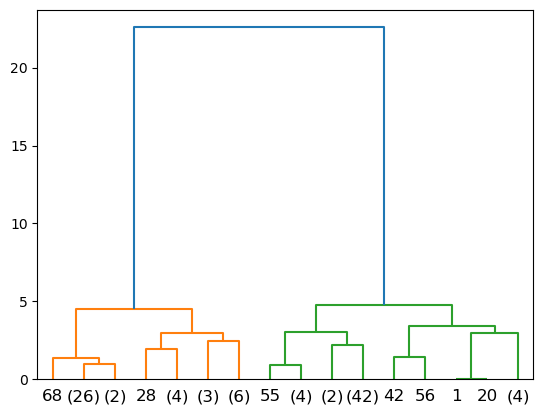

In [54]:
ac = AgglomerativeClustering(linkage='ward',n_clusters=None,distance_threshold=0)

ac.fit(X)

plot_dendrogram(ac, truncate_mode="level", p=3)